In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import pearsonr, spearmanr

TOKENS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
    "blue": "#5477C4",
    "gold": "#B8A037",
    "orange": "#CC6F47",
    "olive": "#71B436",
    "pink": "#BD569B",
}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.facecolor": TOKENS["surface"],
        "axes.facecolor": TOKENS["panel"],
        "axes.edgecolor": TOKENS["axis"],
        "axes.labelcolor": TOKENS["ink"],
        "grid.color": TOKENS["grid"],
        "font.family": "sans-serif",
    },
)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_rows", 120)


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "universal_validator").exists() and (candidate / "log").exists():
            return candidate
    raise FileNotFoundError("Repository root was not found")


REPO_ROOT = find_repo_root(Path.cwd())
RUN_DIR = REPO_ROOT / "log/twitter/jepa/tests/geometry_tc/framework_revalidation_v2"
LEGACY_DIR = REPO_ROOT / "log/twitter/jepa/tests/geometry_tc/seed_0/checkpoint_sweep"
RUN_DIR


PosixPath('/home/dev/ESdB-Embeddings-for-Sequential-data-Benchmark/log/twitter/jepa/tests/geometry_tc/framework_revalidation_v2')

## Data

### 1. Load and validate all epochs


In [2]:
rows = []
for result_path in sorted(RUN_DIR.glob("epoch_*/results.csv")):
    epoch = int(re.search(r"epoch_(\d+)", result_path.parent.name).group(1))
    values = pd.read_csv(result_path, index_col=0)["mean"]
    rows.append({"epoch": epoch, **values.to_dict()})

metrics_by_epoch = pd.DataFrame(rows).sort_values("epoch").set_index("epoch")
downstream_columns = [c for c in metrics_by_epoch if c.startswith("target__")]
embedding_columns = [c for c in metrics_by_epoch if c.startswith("embedding__")]

quality_summary = pd.DataFrame(
    {
        "value": [
            len(metrics_by_epoch),
            metrics_by_epoch.shape[1],
            len(downstream_columns),
            sum("asmi_" in c for c in embedding_columns),
            sum("__lidar__" in c for c in embedding_columns),
            sum("__tc__" in c for c in embedding_columns),
            int(metrics_by_epoch.isna().sum().sum()),
        ]
    },
    index=[
        "epochs", "result_columns", "downstream_metrics", "asmi_columns",
        "lidar_columns", "tc_columns", "nan_values",
    ],
)
display(quality_summary)
assert list(metrics_by_epoch.index) == list(range(1, 21))
assert metrics_by_epoch.isna().sum().sum() == 0


,value
epochs,20
result_columns,196
downstream_metrics,3
asmi_columns,108
lidar_columns,12
tc_columns,6
nan_values,0


## Results

### 2. Downstream trajectories

Raw values are shown separately because classification, regression and anomaly have different scales.


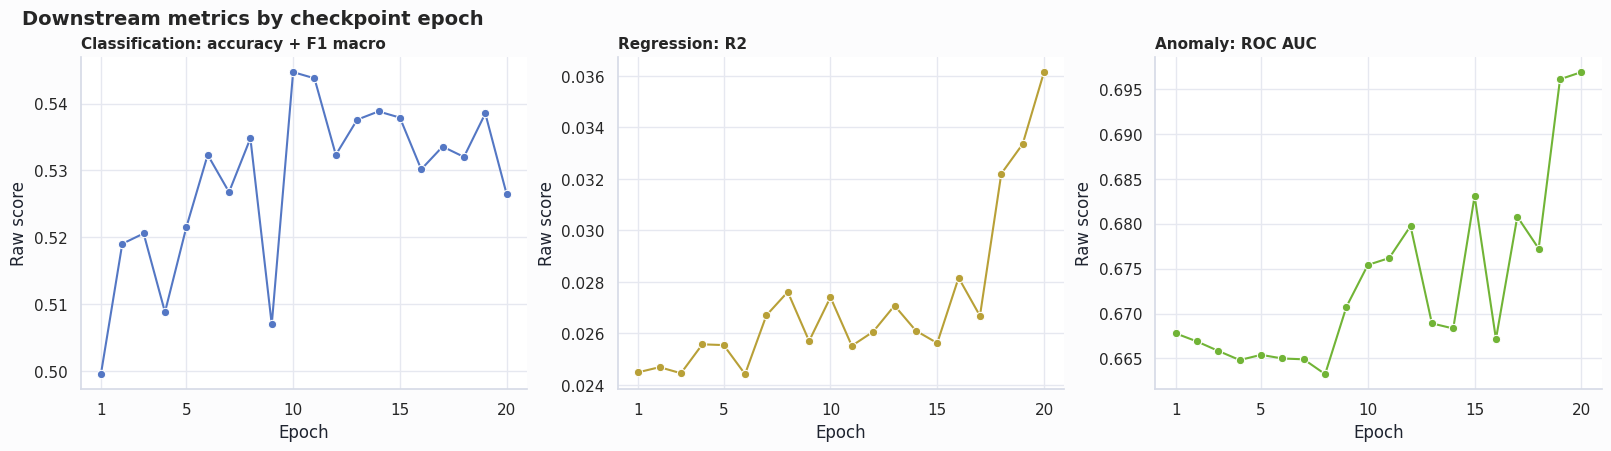

,target__clf__global__accuracy+f1_macro,target__reg_mentions__global__r2,target__anomaly__global__roc_auc
epoch,,,
1,0.4995,0.0245,0.6678
2,0.5190,0.0247,0.6669
3,0.5206,0.0245,0.6658
4,0.5088,0.0256,0.6648
5,0.5215,0.0255,0.6654
6,0.5323,0.0244,0.6650
7,0.5268,0.0267,0.6649
8,0.5348,0.0276,0.6632
9,0.5070,0.0257,0.6708


In [4]:
downstream_labels = {
    "target__clf__global__accuracy+f1_macro": "Classification: accuracy + F1 macro",
    "target__reg_mentions__global__r2": "Regression: R2",
    "target__anomaly__global__roc_auc": "Anomaly: ROC AUC",
}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
colors = [TOKENS["blue"], TOKENS["gold"], TOKENS["olive"]]
for ax, column, color in zip(axes, downstream_columns, colors):
    sns.lineplot(x=metrics_by_epoch.index, y=metrics_by_epoch[column], marker="o", color=color, ax=ax)
    ax.set_title(downstream_labels.get(column, column), loc="left", fontsize=11, fontweight="semibold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Raw score")
    ax.set_xticks([1, 5, 10, 15, 20])
    sns.despine(ax=ax)
fig.suptitle("Downstream metrics by checkpoint epoch", x=0.01, ha="left", fontsize=14, fontweight="semibold")
plt.show()

display(metrics_by_epoch[downstream_columns].round(4))


### 3. Correlations with downstream

The tables rank unique metric trajectories by Spearman correlation. `q` is the Benjamini-Hochberg correction within each downstream task.


In [14]:
def bh_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    order = np.argsort(pvalues)
    ranked = pvalues[order]
    adjusted = ranked * len(ranked) / np.arange(1, len(ranked) + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    result = np.empty_like(adjusted)
    result[order] = np.minimum(adjusted, 1.0)
    return result


def unique_metric_columns(frame):
    selected, seen = [], {}
    for column in frame.columns:
        if not column.startswith("embedding__"):
            continue
        if column.endswith(("__n_samples", "__dim", "__source_effdim", "__target_effdim")):
            continue
        key = tuple(np.round(frame[column].to_numpy(float), 12))
        if key not in seen:
            seen[key] = column
            selected.append(column)
    return selected


correlation_rows = []
for downstream in downstream_columns:
    task_rows = []
    for metric in unique_metric_columns(metrics_by_epoch):
        values = metrics_by_epoch[metric]
        if values.nunique() < 2:
            continue
        pearson = pearsonr(values, metrics_by_epoch[downstream])
        spearman = spearmanr(values, metrics_by_epoch[downstream])
        task_rows.append(
            {
                "downstream": downstream,
                "metric": metric,
                "pearson": pearson.statistic,
                "pearson_p": pearson.pvalue,
                "spearman": spearman.statistic,
                "spearman_p": spearman.pvalue,
            }
        )
    qvalues = bh_adjust([row["spearman_p"] for row in task_rows])
    for row, qvalue in zip(task_rows, qvalues):
        row["spearman_q"] = qvalue
    correlation_rows.extend(task_rows)

correlations = pd.DataFrame(correlation_rows)


def compact_metric_name(value):
    return (
        value.replace("embedding__test__", "")
        .replace("asmi_ksg_pca_whiten_", "asmi_")
        .replace("total_compression", "TC")
    )

for downstream in downstream_columns:
    ranked = correlations[correlations.downstream == downstream].sort_values("spearman")
    top_bottom = pd.concat([ranked.head(10), ranked.tail(10)]).copy()
    top_bottom["metric"] = top_bottom["metric"].map(compact_metric_name)
    print("\n", downstream_labels.get(downstream, downstream))
    display(top_bottom[["metric", "pearson", "pearson_p", "spearman", "spearman_p", "spearman_q"]].round(4))



 Classification: accuracy + F1 macro


,metric,pearson,pearson_p,spearman,spearman_p,spearman_q
105,lidar__jepa_mask_v2_n1024__views_2__reg_0.0001,-0.6248,0.0032,-0.7334,0.0002,0.0208
99,lidar__jepa_mask_v2_n512__views_2__reg_0.0001,-0.6224,0.0034,-0.7048,0.0005,0.0208
102,lidar__jepa_mask_v4_n512__views_4__reg_0.0001,-0.6264,0.0031,-0.6769,0.0010,0.0208
108,lidar__jepa_mask_v4_n1024__views_4__reg_0.0001,-0.6351,0.0026,-0.6762,0.0011,0.0208
98,lidar__jepa_mask_v2_n512__views_2__reg_1e-05,-0.5956,0.0056,-0.6627,0.0015,0.0208
101,lidar__jepa_mask_v4_n512__views_4__reg_1e-05,-0.5997,0.0052,-0.6559,0.0017,0.0208
104,lidar__jepa_mask_v2_n1024__views_2__reg_1e-05,-0.6062,0.0046,-0.6529,0.0018,0.0208
107,lidar__jepa_mask_v4_n1024__views_4__reg_1e-05,-0.6082,0.0044,-0.6461,0.0021,0.0209
106,lidar__jepa_mask_v2_n1024__views_2__reg_0.001,-0.6461,0.0021,-0.5965,0.0055,0.0328
109,lidar__jepa_mask_v4_n1024__views_4__reg_0.001,-0.6525,0.0018,-0.5814,0.0072,0.0328



 Regression: R2


,metric,pearson,pearson_p,spearman,spearman_p,spearman_q
128,target_layer_1__anisotropy,-0.5742,0.0081,-0.7068,0.0005,0.0030
112,global__anisotropy,-0.6879,0.0008,-0.7053,0.0005,0.0030
160,online_layer_1__anisotropy,-0.5610,0.0101,-0.6947,0.0007,0.0034
192,online_projected__anisotropy,-0.6520,0.0018,-0.6571,0.0016,0.0072
144,target_layer_2__anisotropy,-0.4825,0.0312,-0.6211,0.0035,0.0127
176,online_layer_2__anisotropy,-0.4585,0.0420,-0.5534,0.0114,0.0305
207,tc__target_layer_2_to_target_projected__TC,-0.5014,0.0243,-0.4331,0.0565,0.0986
217,lidar__jepa_mask_v4_n1024__views_4__reg_1e-05,-0.3539,0.1259,-0.2872,0.2195,0.3219
214,lidar__jepa_mask_v2_n1024__views_2__reg_1e-05,-0.3538,0.1260,-0.2496,0.2885,0.3967
208,lidar__jepa_mask_v2_n512__views_2__reg_1e-05,-0.3542,0.1255,-0.2226,0.3456,0.4636



 Anomaly: ROC AUC


,metric,pearson,pearson_p,spearman,spearman_p,spearman_q
222,global__anisotropy,-0.6299,0.0029,-0.5910,0.0061,0.0422
238,target_layer_1__anisotropy,-0.5395,0.0141,-0.5669,0.0091,0.0451
317,tc__target_layer_2_to_target_projected__TC,-0.5348,0.0151,-0.5203,0.0187,0.0709
302,online_projected__anisotropy,-0.6157,0.0039,-0.4526,0.0451,0.1142
270,online_layer_1__anisotropy,-0.5003,0.0247,-0.4361,0.0546,0.1155
254,target_layer_2__anisotropy,-0.4297,0.0586,-0.4316,0.0574,0.1168
297,online_layer_2__asmi_sigma1_dim2_k3_m50,0.0336,0.8882,-0.3940,0.0856,0.1520
265,target_layer_2__asmi_sigma1_dim2_k3_m50,-0.0283,0.9057,-0.3789,0.0994,0.1657
264,target_layer_2__asmi_sigma1_dim2_k1_m50,-0.0208,0.9306,-0.3744,0.1038,0.1680
327,lidar__jepa_mask_v4_n1024__views_4__reg_1e-05,-0.2834,0.2259,-0.3383,0.1445,0.2148


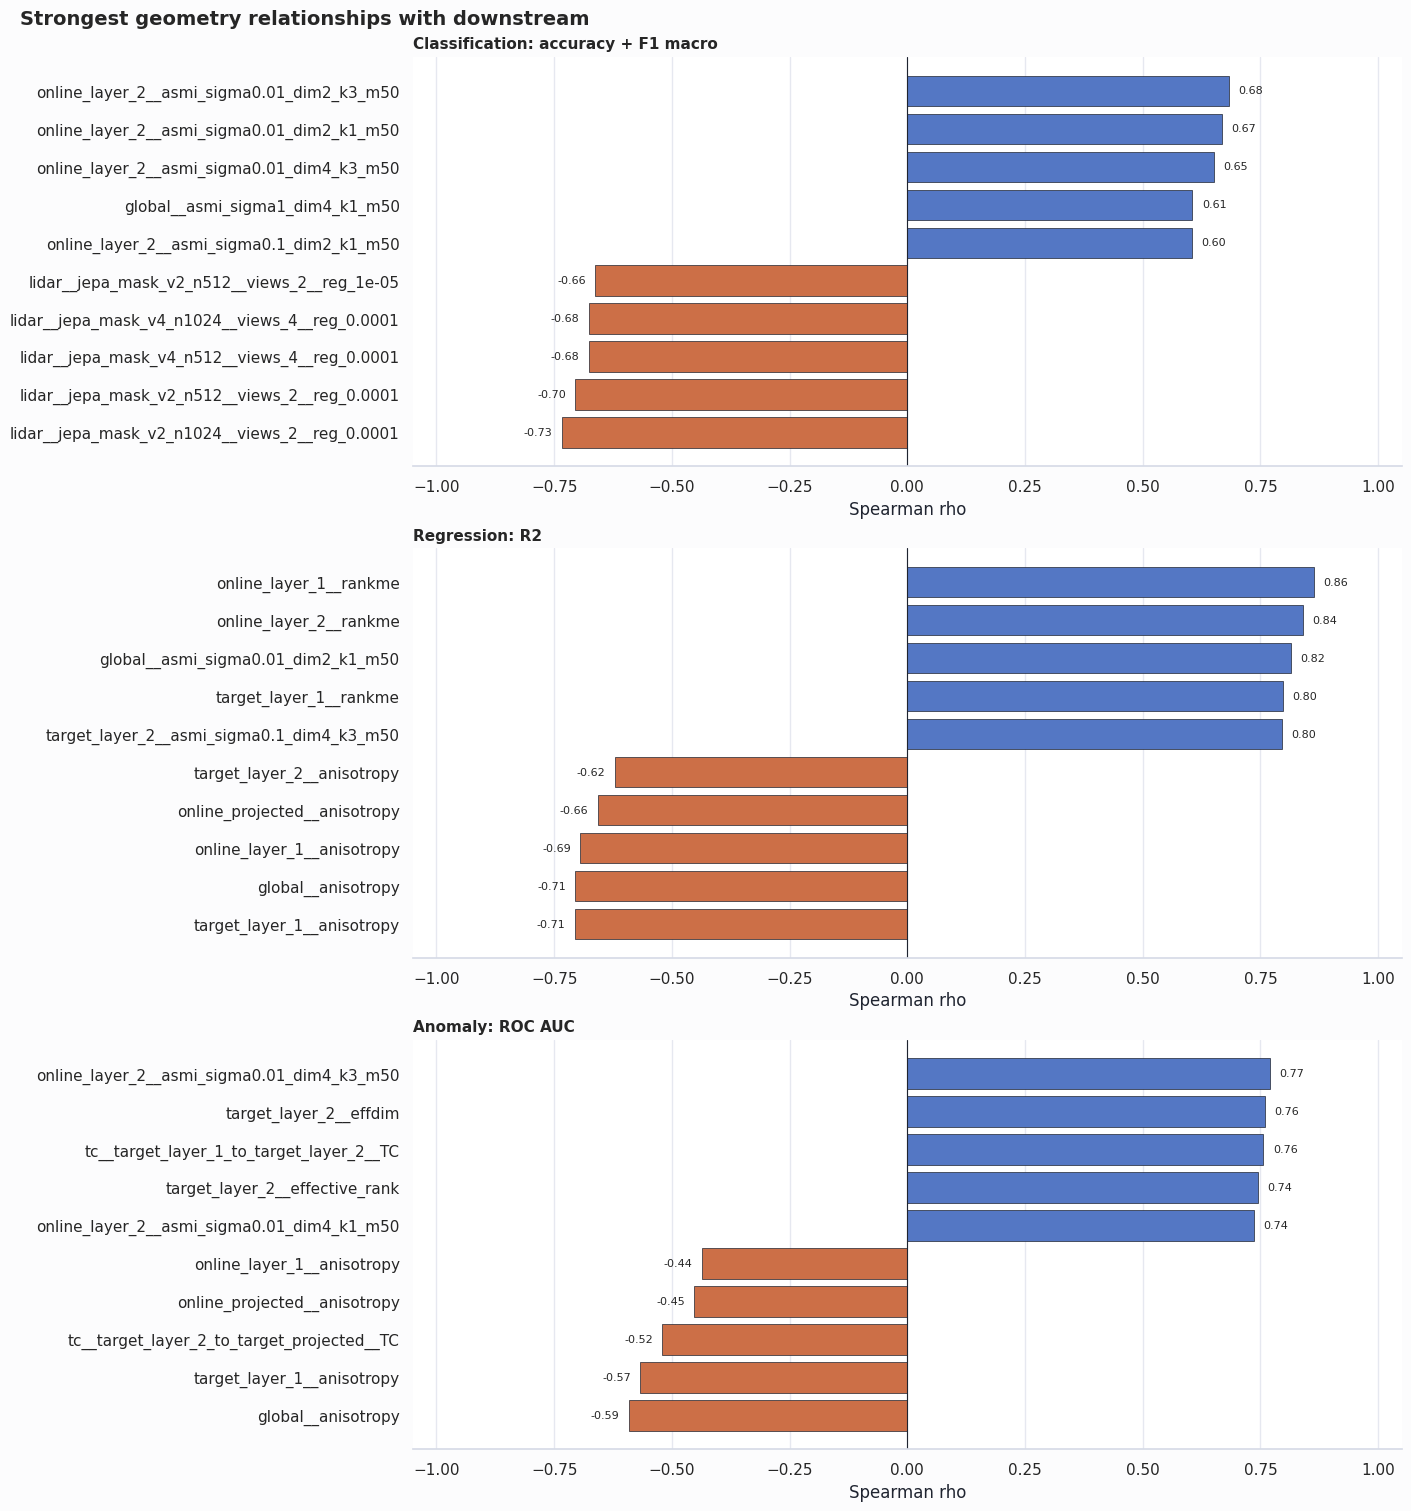

In [7]:
fig, axes = plt.subplots(
    len(downstream_columns),
    1,
    figsize=(14, 5 * len(downstream_columns)),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, downstream in zip(axes, downstream_columns):
    task = correlations[
        correlations.downstream == downstream
    ].dropna(subset=["spearman"])

    selected = pd.concat([
        task.nsmallest(5, "spearman"),
        task.nlargest(5, "spearman"),
    ]).drop_duplicates("metric").sort_values("spearman")

    labels = selected.metric.map(compact_metric_name)
    colors = [
        TOKENS["orange"] if value < 0 else TOKENS["blue"]
        for value in selected.spearman
    ]

    bars = ax.barh(
        labels,
        selected.spearman,
        color=colors,
        edgecolor=TOKENS["ink"],
        linewidth=0.5,
    )

    ax.axvline(0, color=TOKENS["ink"], linewidth=0.8)
    ax.set_xlim(-1.05, 1.05)
    ax.set_xlabel("Spearman rho")
    ax.set_title(
        downstream_labels.get(downstream, downstream),
        loc="left",
        fontsize=11,
        fontweight="semibold",
    )
    ax.grid(axis="y", visible=False)

    for bar, value in zip(bars, selected.spearman):
        ax.text(
            value + (0.02 if value >= 0 else -0.02),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.2f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=8,
        )

    sns.despine(ax=ax, left=True)

fig.suptitle(
    "Strongest geometry relationships with downstream",
    x=0.01,
    ha="left",
    fontsize=14,
    fontweight="semibold",
)

plt.show()

### 4. Raw and standardized trajectories for strongest relationships


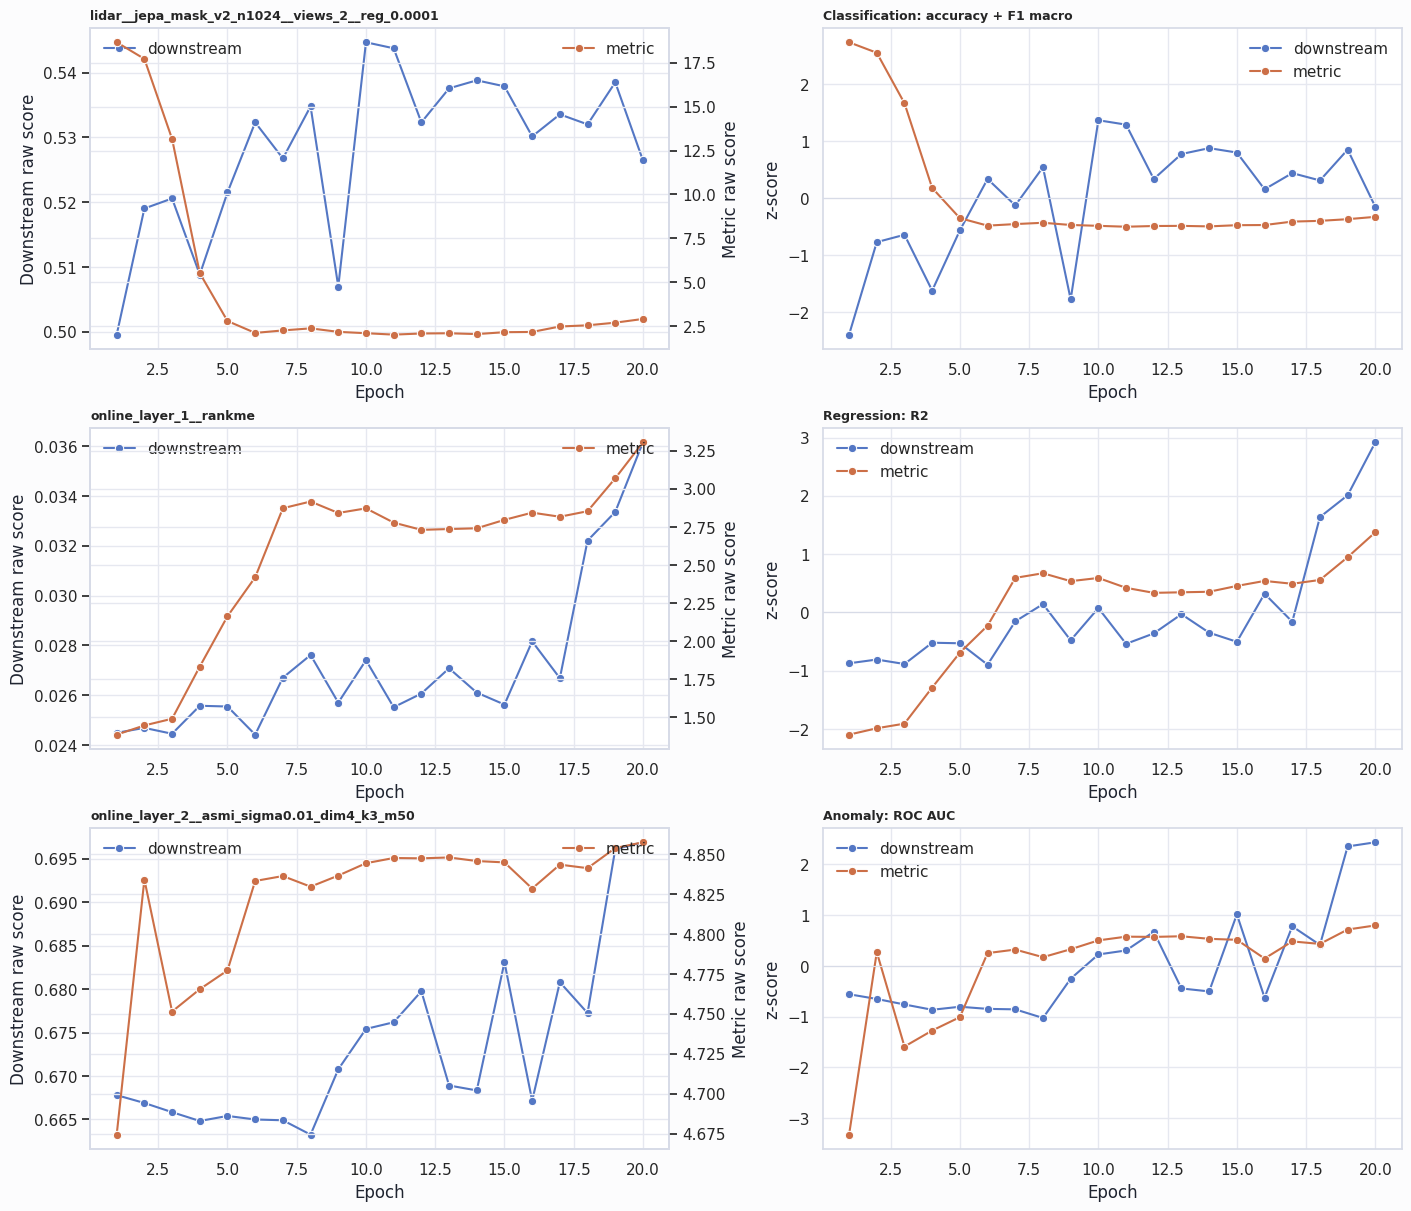

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12), constrained_layout=True)
for row_idx, downstream in enumerate(downstream_columns):
    ranked = correlations[correlations.downstream == downstream]
    metric = ranked.loc[ranked.spearman.abs().idxmax(), "metric"]
    raw = pd.DataFrame({"downstream": metrics_by_epoch[downstream], "metric": metrics_by_epoch[metric]})
    sns.lineplot(x=raw.index, y=raw.downstream, marker="o", color=TOKENS["blue"], label="downstream", ax=axes[row_idx, 0])
    twin = axes[row_idx, 0].twinx()
    sns.lineplot(x=raw.index, y=raw.metric, marker="o", color=TOKENS["orange"], label="metric", ax=twin)
    axes[row_idx, 0].set_title(compact_metric_name(metric), loc="left", fontsize=9, fontweight="semibold")
    axes[row_idx, 0].set_xlabel("Epoch")
    axes[row_idx, 0].set_ylabel("Downstream raw score")
    twin.set_ylabel("Metric raw score")
    axes[row_idx, 0].legend(loc="upper left", frameon=False)
    twin.legend(loc="upper right", frameon=False)

    standardized = (raw - raw.mean()) / raw.std(ddof=0)
    sns.lineplot(data=standardized, x=standardized.index, y="downstream", marker="o", color=TOKENS["blue"], label="downstream", ax=axes[row_idx, 1])
    sns.lineplot(data=standardized, x=standardized.index, y="metric", marker="o", color=TOKENS["orange"], label="metric", ax=axes[row_idx, 1])
    axes[row_idx, 1].axhline(0, color=TOKENS["axis"], linewidth=0.8)
    axes[row_idx, 1].set_xlabel("Epoch")
    axes[row_idx, 1].set_ylabel("z-score")
    axes[row_idx, 1].legend(frameon=False)
    axes[row_idx, 1].set_title(downstream_labels.get(downstream, downstream), loc="left", fontsize=9, fontweight="semibold")
plt.show()


### 5. Total Compression

TC follows the article-oriented direction `log(EffDim(previous) / EffDim(next))` for adjacent stages.


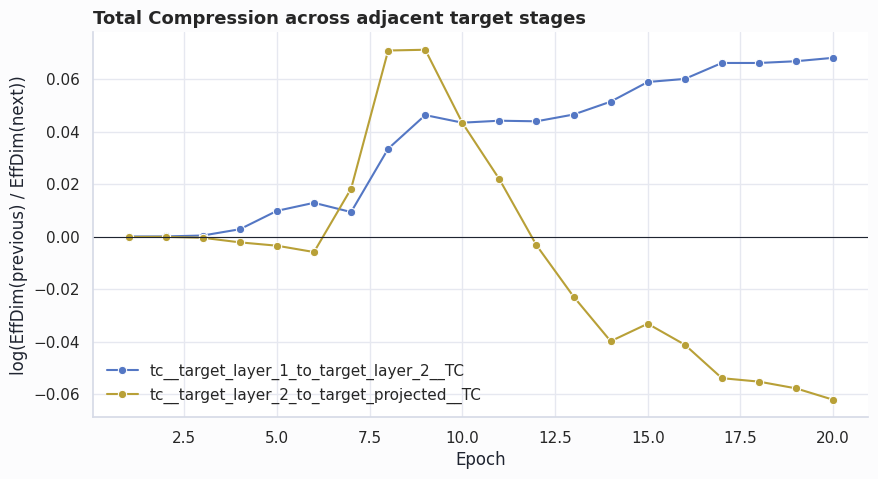

,transition,downstream,spearman,pvalue
0,tc__target_layer_1_to_target_layer_2__TC,Classification: accuracy + F1 macro,0.4897,0.0284
1,tc__target_layer_1_to_target_layer_2__TC,Regression: R2,0.7293,0.0003
2,tc__target_layer_1_to_target_layer_2__TC,Anomaly: ROC AUC,0.7564,0.0001
3,tc__target_layer_2_to_target_projected__TC,Classification: accuracy + F1 macro,-0.1730,0.4658
4,tc__target_layer_2_to_target_projected__TC,Regression: R2,-0.4331,0.0565
5,tc__target_layer_2_to_target_projected__TC,Anomaly: ROC AUC,-0.5203,0.0187


In [9]:
tc_columns = [c for c in metrics_by_epoch if c.endswith("__total_compression")]
tc_long = metrics_by_epoch[tc_columns].reset_index().melt("epoch", var_name="transition", value_name="TC")
tc_long["transition"] = tc_long.transition.map(compact_metric_name)

fig, ax = plt.subplots(figsize=(10, 5))
palette = {name: color for name, color in zip(tc_long.transition.unique(), [TOKENS["blue"], TOKENS["gold"]])}
sns.lineplot(data=tc_long, x="epoch", y="TC", hue="transition", marker="o", palette=palette, ax=ax)
ax.axhline(0, color=TOKENS["ink"], linewidth=0.8)
ax.set_title("Total Compression across adjacent target stages", loc="left", fontsize=13, fontweight="semibold")
ax.set_xlabel("Epoch")
ax.set_ylabel("log(EffDim(previous) / EffDim(next))")
ax.legend(frameon=False, title=None)
sns.despine(ax=ax)
plt.show()

tc_correlation_rows = []
for tc_column in tc_columns:
    for downstream in downstream_columns:
        result = spearmanr(metrics_by_epoch[tc_column], metrics_by_epoch[downstream])
        tc_correlation_rows.append({
            "transition": compact_metric_name(tc_column),
            "downstream": downstream_labels.get(downstream, downstream),
            "spearman": result.statistic,
            "pvalue": result.pvalue,
        })
display(pd.DataFrame(tc_correlation_rows).round(4))


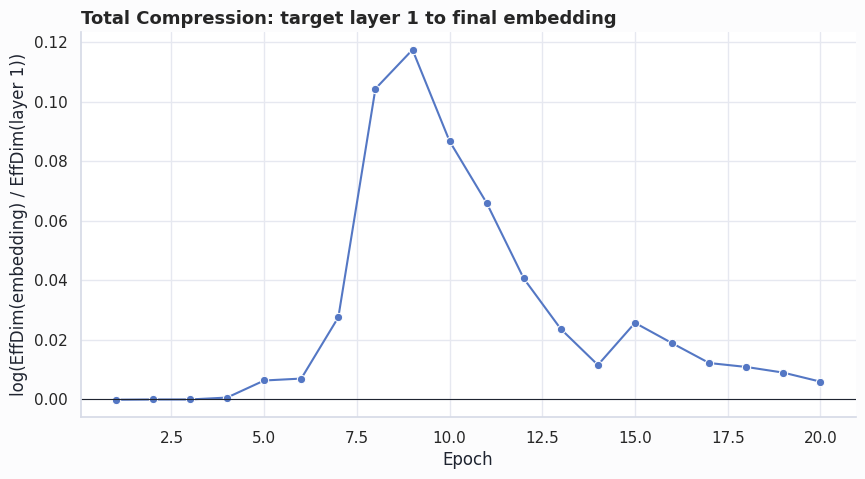

In [12]:
first_layer = "embedding__test__target_layer_1__effdim"
final_embedding = "embedding__test__target_projected__effdim"

total_compression = np.log(
    metrics_by_epoch[final_embedding]
    / metrics_by_epoch[first_layer]
)

# Проверяем: total TC равен сумме локальных log-ratio.
local_tc_columns = [
    "embedding__test__tc__target_layer_1_to_target_layer_2__total_compression",
    "embedding__test__tc__target_layer_2_to_target_projected__total_compression",
]

np.testing.assert_allclose(
    total_compression,
    metrics_by_epoch[local_tc_columns].sum(axis=1),
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    x=metrics_by_epoch.index,
    y=total_compression,
    marker="o",
    color=TOKENS["blue"],
    ax=ax,
)

ax.axhline(0, color=TOKENS["ink"], linewidth=0.8)
ax.set_title(
    "Total Compression: target layer 1 to final embedding",
    loc="left",
    fontsize=13,
    fontweight="semibold",
)
ax.set_xlabel("Epoch")
ax.set_ylabel("log(EffDim(embedding) / EffDim(layer 1))")
sns.despine(ax=ax)

plt.show()

In [13]:
tc_correlations = []

for downstream in downstream_columns:
    result = spearmanr(
        total_compression,
        metrics_by_epoch[downstream],
    )
    tc_correlations.append({
        "downstream": downstream_labels.get(downstream, downstream),
        "spearman": result.statistic,
        "pvalue": result.pvalue,
    })

display(pd.DataFrame(tc_correlations).round(4))

,downstream,spearman,pvalue
0,Classification: accuracy + F1 macro,0.5288,0.0165
1,Regression: R2,0.3474,0.1334
2,Anomaly: ROC AUC,0.1489,0.5310


### 6. LiDAR and aSMI hyperparameter views


,views,sample_size,reg,downstream,spearman,pvalue
29,4,1024,0.0000,Anomaly: ROC AUC,-0.3383,0.1445
20,2,1024,0.0000,Anomaly: ROC AUC,-0.3218,0.1665
2,2,512,0.0000,Anomaly: ROC AUC,-0.3098,0.1838
11,4,512,0.0000,Anomaly: ROC AUC,-0.2797,0.2323
23,2,1024,0.0001,Anomaly: ROC AUC,-0.2045,0.3871
5,2,512,0.0001,Anomaly: ROC AUC,-0.1865,0.4312
32,4,1024,0.0001,Anomaly: ROC AUC,-0.1564,0.5103
14,4,512,0.0001,Anomaly: ROC AUC,-0.0977,0.6818
35,4,1024,0.0010,Anomaly: ROC AUC,-0.0662,0.7817
17,4,512,0.0010,Anomaly: ROC AUC,-0.0526,0.8256


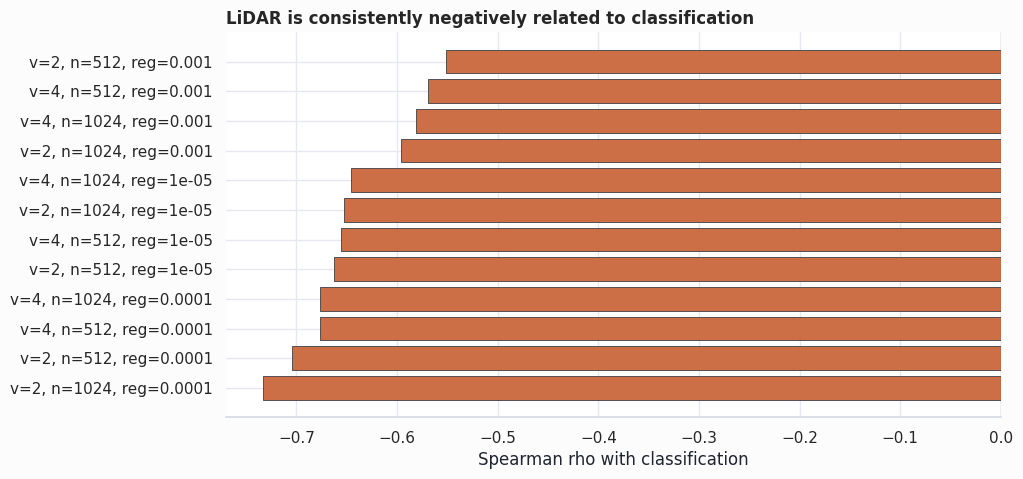

In [10]:
lidar_columns = [c for c in metrics_by_epoch if "__lidar__" in c]
lidar_rows = []
for column in lidar_columns:
    match = re.search(r"v(\d+)_n(\d+).*reg_([0-9.e-]+)$", column)
    for downstream in downstream_columns:
        result = spearmanr(metrics_by_epoch[column], metrics_by_epoch[downstream])
        lidar_rows.append({
            "views": int(match.group(1)),
            "sample_size": int(match.group(2)),
            "reg": float(match.group(3)),
            "downstream": downstream_labels.get(downstream, downstream),
            "spearman": result.statistic,
            "pvalue": result.pvalue,
        })
lidar_correlations = pd.DataFrame(lidar_rows)
display(lidar_correlations.sort_values(["downstream", "spearman"]).round(4))

classification_lidar = lidar_correlations[lidar_correlations.downstream.str.startswith("Classification")].copy()
classification_lidar["setting"] = (
    "v=" + classification_lidar.views.astype(str)
    + ", n=" + classification_lidar.sample_size.astype(str)
    + ", reg=" + classification_lidar.reg.map(lambda x: f"{x:g}")
)
fig, ax = plt.subplots(figsize=(10, 5))
classification_lidar = classification_lidar.sort_values("spearman")
ax.barh(classification_lidar.setting, classification_lidar.spearman, color=TOKENS["orange"], edgecolor=TOKENS["ink"], linewidth=0.5)
ax.axvline(0, color=TOKENS["ink"], linewidth=0.8)
ax.set_xlabel("Spearman rho with classification")
ax.set_title("LiDAR is consistently negatively related to classification", loc="left", fontsize=12, fontweight="semibold")
sns.despine(ax=ax, left=True)
plt.show()


In [11]:
asmi_columns = [c for c in metrics_by_epoch if "asmi_ksg" in c]
asmi_rows = []
for column in asmi_columns:
    match = re.search(r"sigma([0-9.]+)_dim(\d+)_k(\d+)_m(\d+)$", column)
    source = column.split("__")[2]
    for downstream in downstream_columns:
        result = spearmanr(metrics_by_epoch[column], metrics_by_epoch[downstream])
        asmi_rows.append({
            "source": source,
            "sigma": float(match.group(1)),
            "dim": int(match.group(2)),
            "k": int(match.group(3)),
            "projections": int(match.group(4)),
            "downstream": downstream_labels.get(downstream, downstream),
            "spearman": result.statistic,
            "pvalue": result.pvalue,
        })
asmi_correlations = pd.DataFrame(asmi_rows)

for downstream in asmi_correlations.downstream.unique():
    print("\n", downstream)
    display(
        asmi_correlations[asmi_correlations.downstream == downstream]
        .sort_values("spearman")
        .iloc[np.r_[0:5, -5:0]][["source", "sigma", "dim", "k", "spearman", "pvalue"]]
        .round(4)
    )



 Classification: accuracy + F1 macro


,source,sigma,dim,k,spearman,pvalue
99,target_layer_2,1.00,2,3,-0.1986,0.4013
135,target_hidden,1.00,2,3,-0.1986,0.4013
279,online_hidden,1.00,2,3,-0.1211,0.6111
243,online_layer_2,1.00,2,3,-0.1211,0.6111
132,target_hidden,1.00,2,1,-0.0745,0.7550
225,online_layer_2,0.01,4,3,0.6506,0.0019
216,online_layer_2,0.01,2,1,0.6687,0.0013
252,online_hidden,0.01,2,1,0.6687,0.0013
255,online_hidden,0.01,2,3,0.6822,0.0009
219,online_layer_2,0.01,2,3,0.6822,0.0009



 Regression: R2


,source,sigma,dim,k,spearman,pvalue
280,online_hidden,1.00,2,3,-0.2060,0.3835
244,online_layer_2,1.00,2,3,-0.2060,0.3835
277,online_hidden,1.00,2,1,-0.1098,0.6450
241,online_layer_2,1.00,2,1,-0.1098,0.6450
133,target_hidden,1.00,2,1,-0.0571,0.8109
91,target_layer_2,0.10,4,1,0.7805,0.0000
94,target_layer_2,0.10,4,3,0.7955,0.0000
130,target_hidden,0.10,4,3,0.7955,0.0000
145,target_projected,0.01,2,1,0.8150,0.0000
1,global,0.01,2,1,0.8150,0.0000



 Anomaly: ROC AUC


,source,sigma,dim,k,spearman,pvalue
245,online_layer_2,1.00,2,3,-0.3940,0.0856
281,online_hidden,1.00,2,3,-0.3940,0.0856
137,target_hidden,1.00,2,3,-0.3789,0.0994
101,target_layer_2,1.00,2,3,-0.3789,0.0994
134,target_hidden,1.00,2,1,-0.3744,0.1038
80,target_layer_2,0.01,4,1,0.6782,0.0010
224,online_layer_2,0.01,4,1,0.7353,0.0002
260,online_hidden,0.01,4,1,0.7353,0.0002
263,online_hidden,0.01,4,3,0.7699,0.0001
227,online_layer_2,0.01,4,3,0.7699,0.0001
